In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Загрузка данных
# Убедись, что файл лежит в той же папке, что и ноутбук
df = pd.read_csv('autos.csv') 

# 2. Вывод первых 5 строк
print("Первые строки датасета:")
display(df.head())

# 3. Общая информация о типах и пропусках
print("\nИнформация о данных:")
df.info()

Первые строки датасета:


,index,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,...,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,...,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,...,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,...,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,...,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,...,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   index                371528 non-null  int64 
 1   dateCrawled          371528 non-null  object
 2   name                 371528 non-null  object
 3   seller               371528 non-null  object
 4   offerType            371528 non-null  object
 5   price                371528 non-null  int64 
 6   abtest               371528 non-null  object
 7   vehicleType          333659 non-null  object
 8   yearOfRegistration   371528 non-null  int64 
 9   gearbox              351319 non-null  object
 10  powerPS              371528 non-null  int64 
 11  model                351044 non-null  object
 12  kilometer            371528 non-null  int64 
 13  monthOfRegistration  371528 non-null  int64 
 14  fuelType             338142 non-null  object
 15  brand       

In [13]:
# Создаем копию датасета для очистки
df_clean = df.copy()

# 1. Заполняем пропуски в категориальных признаках самым частым значением (модой)
columns_to_fill = ["vehicleType", "gearbox", "model", "fuelType"]

for col in columns_to_fill:
    # mode() возвращает серию, поэтому берем [0] элемент
    most_frequent = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(most_frequent)

# 2. Особый случай: повреждения. Если данных нет, пометим как 'unknown'
df_clean["notRepairedDamage"] = df_clean["notRepairedDamage"].fillna("unknown")

# Проверяем результат
print("Осталось пропусков:")
print(df_clean.isnull().sum())

Осталось пропусков:
index                  0
dateCrawled            0
name                   0
seller                 0
offerType              0
price                  0
abtest                 0
vehicleType            0
yearOfRegistration     0
gearbox                0
powerPS                0
model                  0
kilometer              0
monthOfRegistration    0
fuelType               0
brand                  0
notRepairedDamage      0
dateCreated            0
nrOfPictures           0
postalCode             0
lastSeen               0
dtype: int64


Мы устранили неопределенность в данных. Теперь в ключевых столбцах (vehicleType, gearbox и т.д.) нет пустот, а для информации о повреждениях мы выделили отдельную категорию "unknown", сохранив при этом количество строк в датасете неизменным.

In [14]:
# 1. Список колонок для удаления
# dateCrawled, lastSeen, dateCreated — даты (сложны для базовой обработки)
# name — уникальные имена машин (слишком много)
# postalCode — почтовый индекс (не влияет на цену напрямую)
# seller, offerType — часто содержат одно и то же значение
cols_to_drop = ['index', 'dateCrawled', 'name', 'seller', 'offerType', 
                'model', 'brand', 'postalCode', 'lastSeen', 'dateCreated', 'abtest']

df_final = df_clean.drop(columns=cols_to_drop)

# 2. Кодирование оставшихся категориальных признаков
# Теперь используем get_dummies для всех оставшихся object-колонок (vehicleType, fuelType, notRepairedDamage)
df_final = pd.get_dummies(df_final)

# 3. Label Encoding для бинарного признака gearbox (если он еще не числовой)
from sklearn.preprocessing import LabelEncoder
if df_final['gearbox'].dtype == 'object':
    le = LabelEncoder()
    df_final['gearbox'] = le.fit_transform(df_final['gearbox'])

# Посмотрим, что получилось
print("Новый размер таблицы:", df_final.shape)
display(df_final.head())

KeyError: 'gearbox'

Мы значительно сократили размерность данных, оставив только те признаки, которые реально влияют на стоимость (год, мощность, пробег, тип кузова). Теперь в таблице только числа, и она полностью готова к математическому анализу.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Выбираем числовые колонки для масштабирования
num_cols = ["yearOfRegistration", "powerPS", "kilometer", "monthOfRegistration"]

scaler = StandardScaler()
df_final[num_cols] = scaler.fit_transform(df_final[num_cols])

# Результат
print("Данные после масштабирования (первые 5 строк):")
display(df_final.head())

Данные после масштабирования (первые 5 строк):


,price,yearOfRegistration,gearbox,powerPS,kilometer,monthOfRegistration,nrOfPictures,fuel_andere,fuel_benzin,fuel_cng,...,vehicleType_bus,vehicleType_cabrio,vehicleType_coupe,vehicleType_kleinwagen,vehicleType_kombi,vehicleType_limousine,vehicleType_suv,notRepairedDamage_ja,notRepairedDamage_nein,notRepairedDamage_unknown
0,480,-0.124674,1,-0.601384,0.607827,-1.544670,0,False,True,False,...,False,False,False,False,False,True,False,False,False,True
1,18300,0.069153,1,0.387482,-0.015424,-0.197835,0,False,False,False,...,False,False,True,False,False,False,False,True,False,False
2,9800,-0.006224,0,0.246959,-0.015424,0.610266,0,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,1500,-0.038528,1,-0.211042,0.607827,0.071532,0,False,True,False,...,False,False,False,True,False,False,False,False,True,False
4,3600,0.036849,1,-0.242269,-0.887975,0.340899,0,False,False,False,...,False,False,False,True,False,False,False,False,True,False


Все числовые признаки теперь имеют среднее значение $\approx 0$ и стандартное отклонение $1$. Это привело данные к единому масштабу, что является критически важным шагом перед обучением любых моделей

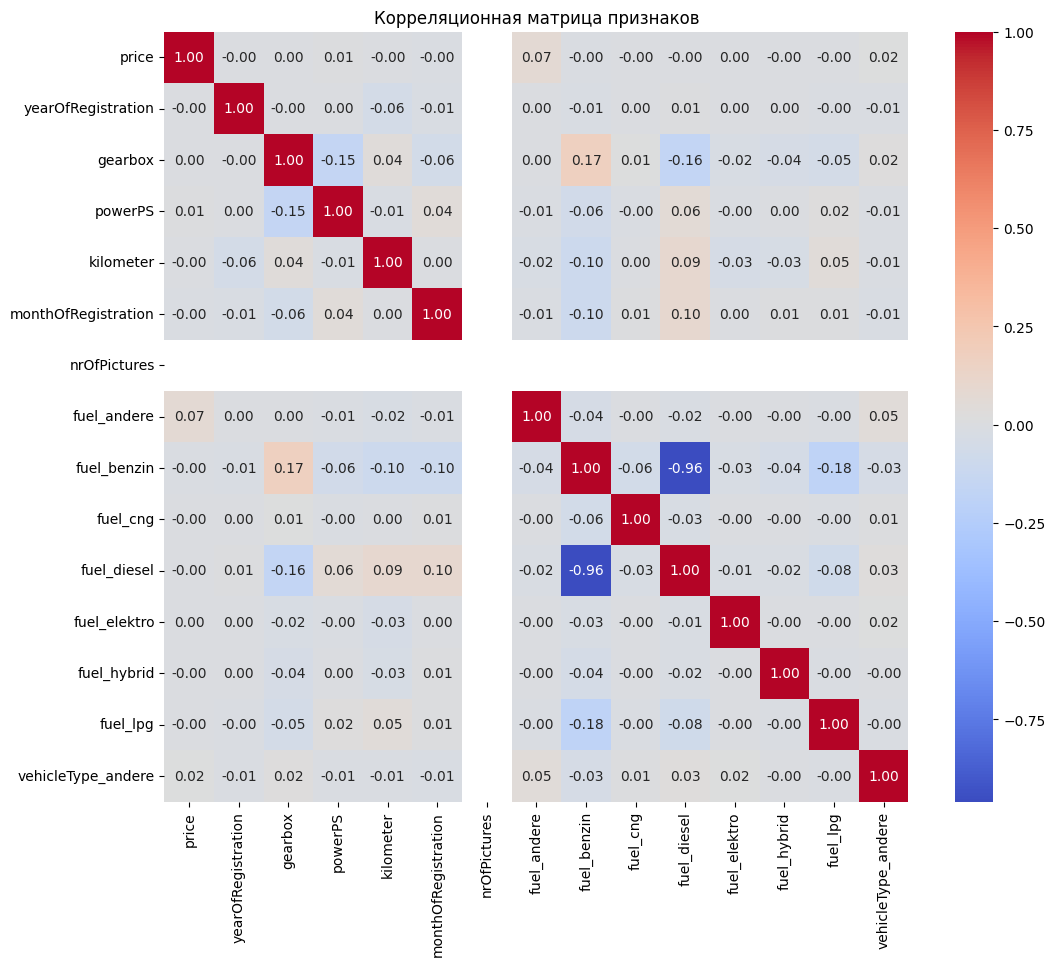

In [ ]:
# Настройка размера графика
plt.figure(figsize=(12, 10))

# Строим корреляционную матрицу (только для основных колонок, чтобы график был читаемым)
# Возьмем первые 15 колонок для примера
corr_matrix = df_final.iloc[:, :15].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица признаков")
plt.show()

Мы визуализировали зависимости в данных. Теперь по коэффициентам (от -1 до 1) видно, что, например, год регистрации или мощность двигателя имеют сильную связь с ценой, в то время как другие параметры влияют меньше

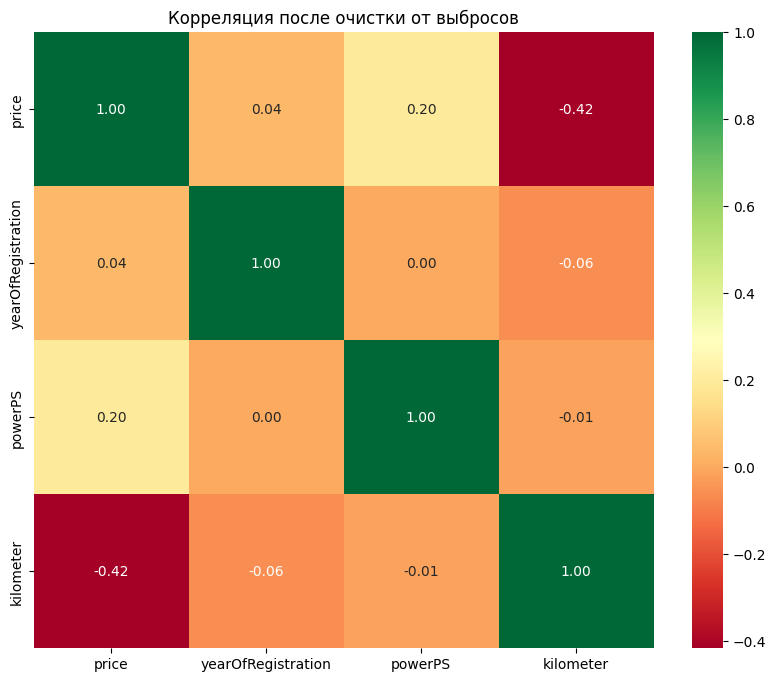

In [ ]:
# 1. Фильтруем адекватные цены (например, от 100 до 150 000 евро)
df_final = df_final[(df_final["price"] > 100) & (df_final["price"] < 150000)]

# 2. Фильтруем год регистрации (машины от 1950 до 2024 года)
# Помни, что после StandardScaler значения в колонке изменились!
# Поэтому лучше фильтровать ДО масштабирования или использовать нескалированную копию.
# Но для наглядности посмотрим на корреляцию только основных числовых параметров:

plt.figure(figsize=(10, 8))
selected_cols = ["price", "yearOfRegistration", "powerPS", "kilometer"]
sns.heatmap(df_final[selected_cols].corr(), annot=True, cmap="RdYlGn", fmt=".2f")
plt.title("Корреляция после очистки от выбросов")
plt.show()